In [1]:
#!pip install rdkit
#!pip install cirpy
#!pip install pandas
#!pip install matplotlib
#!pip install tqdm

In [ ]:
print('hello world2')

hello world


In [3]:
! which jupyter

/opt/conda/envs/SpecToMol/bin/jupyter


In [4]:
! conda env list

# conda environments:
#
base                     /opt/conda
SpecToMol             *  /opt/conda/envs/SpecToMol



In [5]:
! nvidia-smi

Tue Feb 25 14:39:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.04              Driver Version: 561.17         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro M4000                   On  |   00000000:03:00.0  On |                  N/A |
| 48%   46C    P8             21W /  120W |     625MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os

import pandas as pd
import math
import cirpy
import matplotlib.pyplot as plt
from rdkit.Chem import rdMolDescriptors

from tqdm import tqdm

from Code.Utils.util_methods import NNUtils


## Provide the data

In [7]:
#PATH = "../Dataset/nist_08_Common_all_smiles.pkl"
PATH = "../Dataset/nist_08_Common__CHO1_NO_AROMATIC.pkl"
BASE = ".."
MAX_MW = int(os.getenv("MAX_MASS")) # Maximum mass weight to consider
INFER_SMILES = False # Must stay false. Only set to True if you want to run the inference of the SMILES from the name and CAS number. It will take a long time.
DELETE_AROMATICS = False # Only set to True if you want to delete the aromatic molecules.

## Extract the data

In [8]:
# flag to know if the dataset is the original one, so it will check the SMILES from the name and CAS number
if PATH == "../Dataset/nist_08_Common_all_smiles.pkl":
    f_original_dataset = True
else:
    f_original_dataset = False

In [9]:
if PATH.split('.')[-1] == 'csv':
    df = NNUtils.read_big_csv(PATH)
elif PATH.split('.')[-1] == 'pkl':
    df = pd.read_pickle(PATH)
else:
    raise Exception("The file must be a csv or pkl file")
PATH

'../Dataset/nist_08_Common__CHO1_NO_AROMATIC.pkl'

In [10]:
df.head()

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz996,mz997,mz998,mz999,mz1000,Filter_Form,smiles,Arom,Filter,filter
14,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)(CC)C(C)=O,0,1,1
19,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC=C(C)C(C)O,0,1,1
20,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCCCOCCC=C,0,1,1
31,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCC(C)(C)C(C)=O,0,1,1
33,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CC(O)(CC=C)CC=C,0,1,1


In [11]:
df.shape

(6025, 1009)

In [12]:
# change the column names smiles to SMILES
df.rename(columns={'smiles': 'SMILES'}, inplace=True)
print(df["SMILES"].value_counts())

SMILES
CC1CCC2C1C3C(CCC24CO4)C3(C)C                                                             12
OC1C2CCC(C2)C1C3CCCCC3                                                                   12
CC1CCC2C1C3C(CCC2(C)O)C3(C)C                                                             10
CC(=C)C1CCC2(C)OC2C1                                                                      9
CC1(C)CCCC2(O)C(C)(C)C3CCC12C3                                                            7
                                                                                         ..
CCC(O)C(C)(C)CC                                                                           1
CC(C)(O)C1CCC1                                                                            1
CC(C)=CC(C=C)C(C)(C)O                                                                     1
CCCC(C)OC                                                                                 1
CC(=C\C=C\C=C(C)\C=C\C=C(C)\C=C\C1=C(C)C(=O)CCC1(C)C)/C=C/C=C(C)/C=C/C2=C

In [13]:
c=0
for smile in df["SMILES"]:
  #print(smile)
  if smile == None:
    c+=1
  if isinstance(smile, float) and math.isnan(smile):
    c+=1

print(f'{c} None or NaN values')
nb_invalid_smiles = c

0 None or NaN values


## Remove excess columns

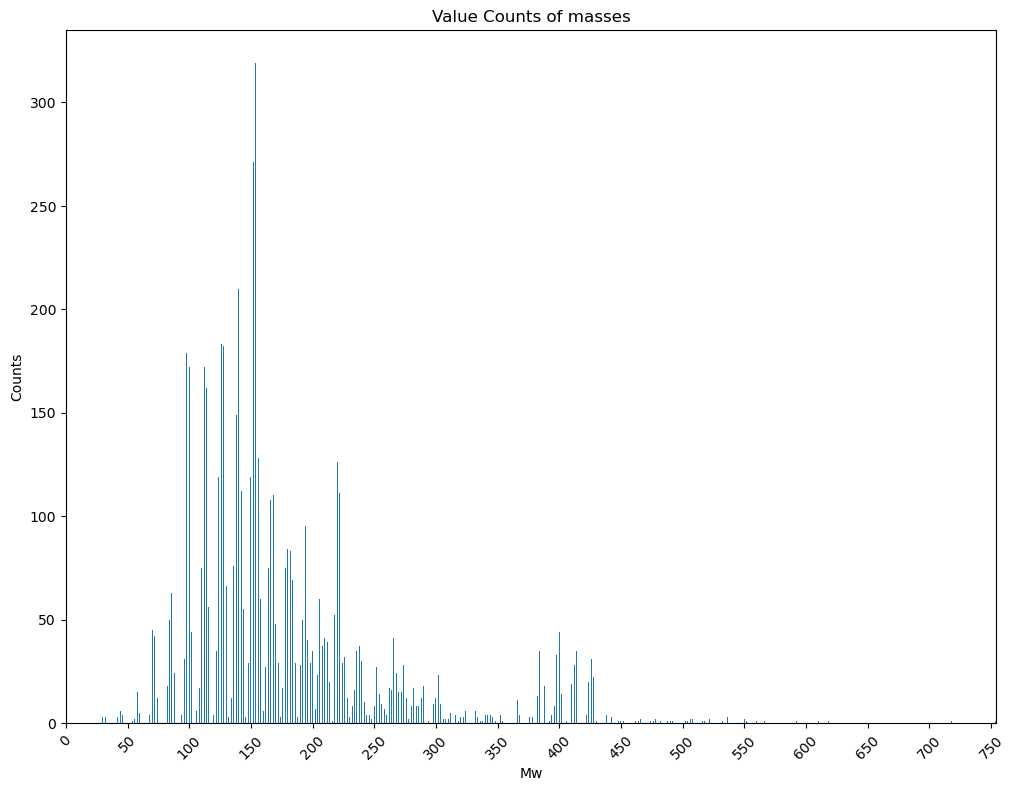

In [14]:
value_counts = df['Mw'].value_counts().sort_index()

# Plotting the value counts
plt.figure(figsize=(12, 9))
plt.bar(value_counts.index, value_counts.values)  # Using a bar plot
plt.title('Value Counts of masses')
plt.xlabel('Mw')
plt.ylabel('Counts')

# Set x-axis limits from 0 to the max value
plt.xlim(0, value_counts.index.max())

# Adjusting the x-ticks to show every 50th element
plt.xticks(range(0, value_counts.index.max() + 1, 50), rotation=45)
plt.show()

<Axes: >

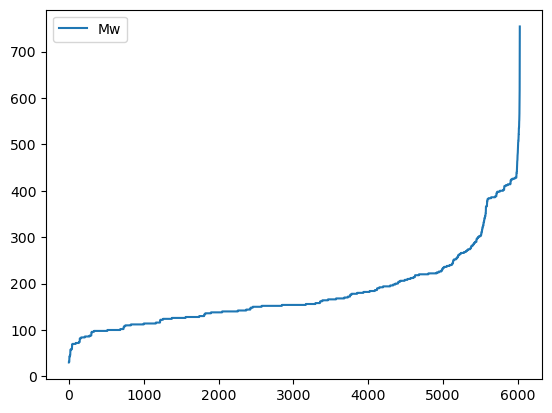

In [15]:
df[["Mw"]].sort_values("Mw").reset_index(drop=True).plot()

-> cut out from mz600

In [16]:
try:
    # assuming you have a DataFrame called df and want to delete columns between 'start_column' and 'end_column'
    start_column = 'mz'+str(MAX_MW+1)
    end_column = 'mz1000'
    
    # finding the index positions of the start and end columns
    start_idx = df.columns.get_loc(start_column)
    end_idx = df.columns.get_loc(end_column) + 1  # add 1 to include the end column
    
    # creating a list of column names to delete
    columns_to_delete = df.columns[start_idx:end_idx]
    
    # deleting the specified range of columns
    df.drop(columns=columns_to_delete, inplace=True)

except Exception as e:
    print(e)

In [17]:
df.reset_index(drop=True, inplace=True)
df.head()

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,Arom,Filter,filter
0,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)(CC)C(C)=O,0,1,1
1,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC=C(C)C(C)O,0,1,1
2,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCCCOCCC=C,0,1,1
3,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCC(C)(C)C(C)=O,0,1,1
4,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CC(O)(CC=C)CC=C,0,1,1


### Verify and delete the mz columns that have 0 sum

Text(0, 0.5, 'Sum')

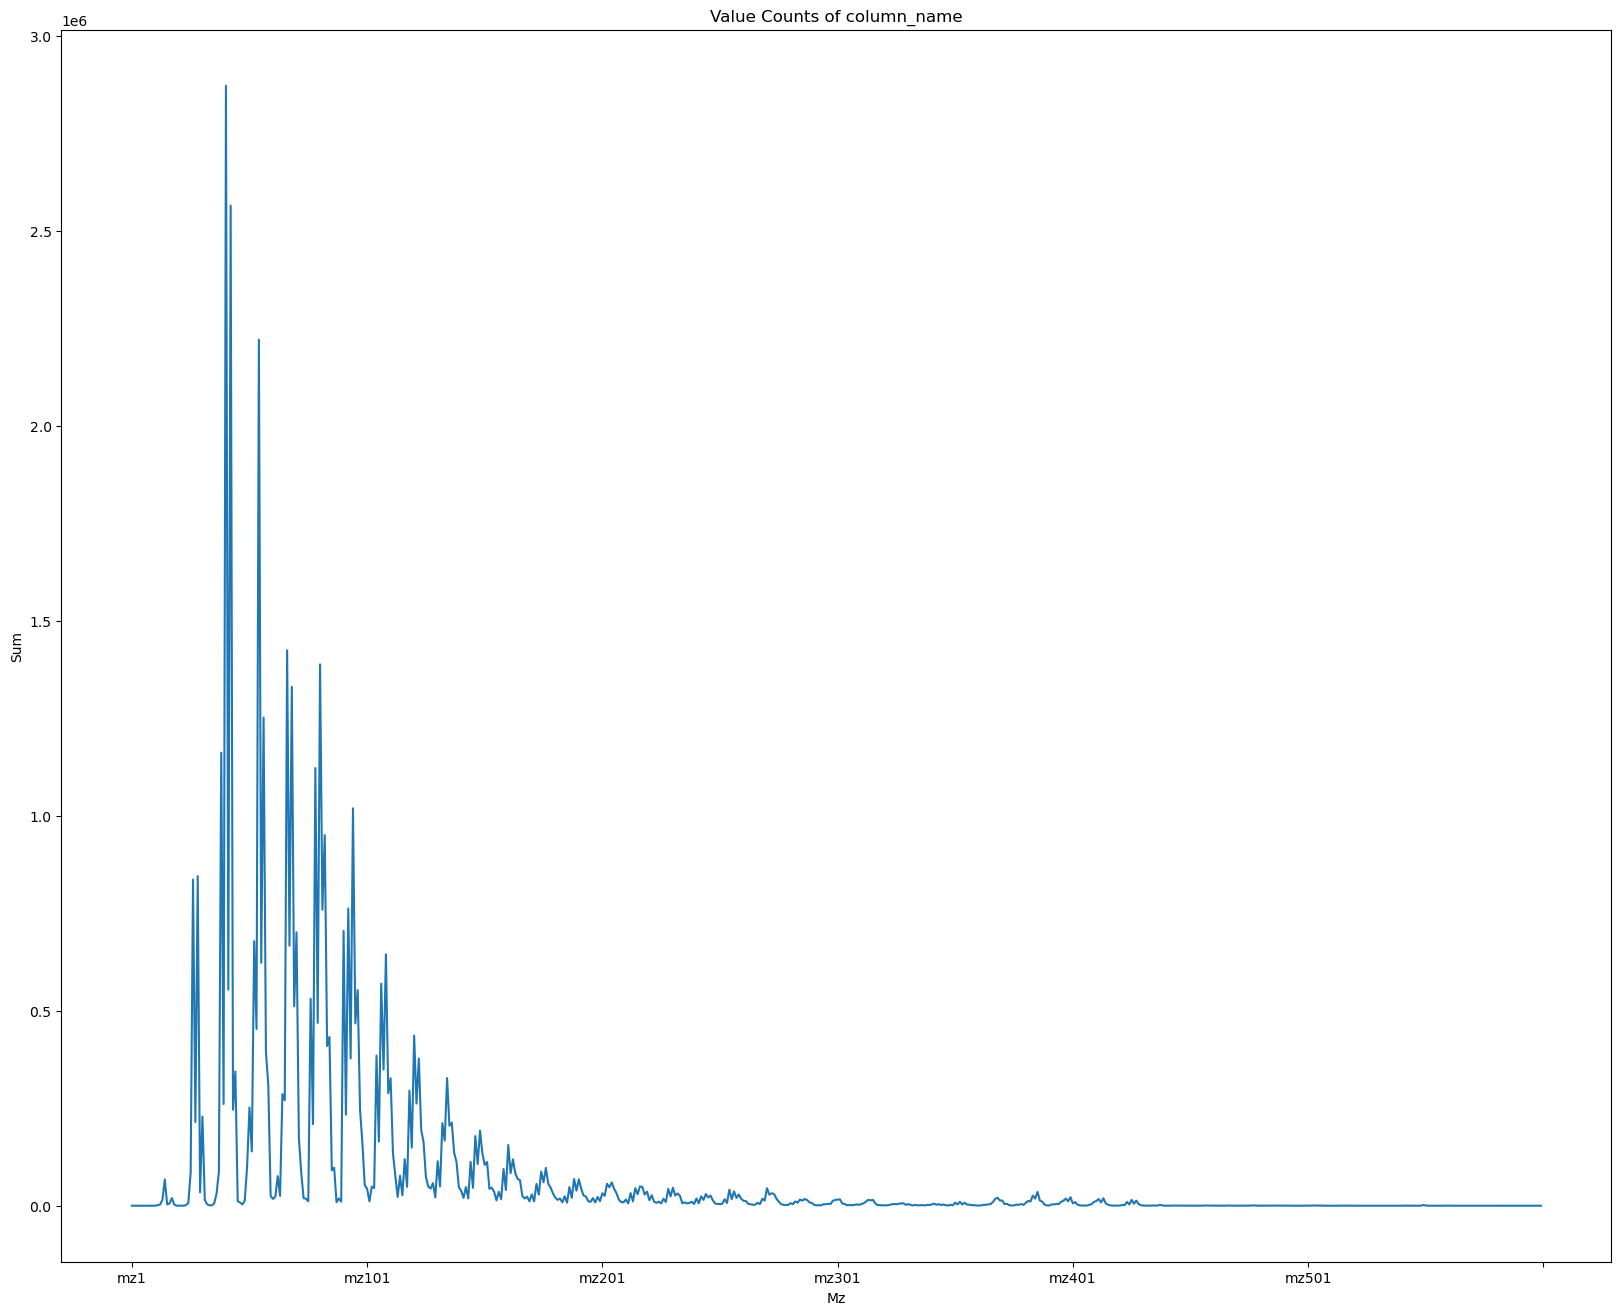

In [18]:
sum_of_masses= df.loc[:, 'mz1':'mz600'].sum()

# Plotting the value counts
plt.figure(figsize=(20, 16))
sum_of_masses.plot(kind='line')  # Using a bar plot
plt.title('Value Counts of column_name')
plt.xlabel('Mz')
plt.ylabel('Sum')

In [19]:
zero_masses = sum_of_masses[sum_of_masses <= 0].index.tolist()
zero_masses

['mz1',
 'mz3',
 'mz5',
 'mz6',
 'mz7',
 'mz8',
 'mz9',
 'mz512',
 'mz554',
 'mz555',
 'mz557',
 'mz567',
 'mz570',
 'mz578',
 'mz579',
 'mz580',
 'mz584',
 'mz585',
 'mz586',
 'mz587',
 'mz594',
 'mz598',
 'mz599']

## Transform CAS number or name to smiles

### Test cases

In [20]:
test_name = df["Name"][0]
test_name

'2-Pentanone, 3-ethyl-3-methyl-'

In [21]:
test_inchikey = "BQJCRHHNABKAKU-KBQPJGBKSA-N"
test_inchikey

'BQJCRHHNABKAKU-KBQPJGBKSA-N'

In [22]:
test_cas = df["Cas"][0]
test_cas

'19780-65-5'

In [23]:
#cirpy.resolve(test_name, 'smiles')

In [24]:
# inchikey_smiles = cirpy.resolve(test_inchikey, 'smiles')
# NNUtils.draw_molecule(inchikey_smiles)
# inchikey_smiles

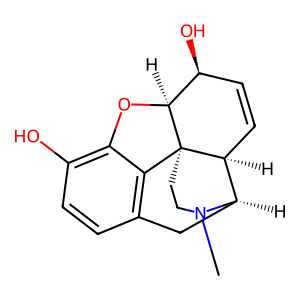

In [25]:
NNUtils.draw_molecule("CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5")

In [26]:
# cirpy.resolve(test_cas, 'smiles')

### Transformation

In [27]:
#smiles_name_cas = pd.DataFrame(columns=['smiles_name','smiles_cas'])

if INFER_SMILES:

    overwrite = False # overwrites existing, if it doesn't exit, it creates
    
    if overwrite:
      with open(BASE+"/Dataset/smiles_name_cas.csv", 'w') as file:
          # Write the string data to the file
          file.write('no,smile_name,smile_cas\n')
    
    
    start = 205054 #included
    for row in range(start, df.shape[0]):
      if row%1000 == 0 and row != 0:
        print(row)
        #break
      name = df['Name'].iloc[row]
      smile_name = cirpy.resolve(name, 'smiles')
      cas = df['Cas'].iloc[row]
      try:
        smile_cas = cirpy.resolve(cas, 'smiles')
        if smile_cas is None:
          smile_cas = smile_name
      except:
        smile_cas = smile_name
        #print(cas)
      #smiles_name_cas.loc[len(smiles_name_cas)] = [smile_name, smile_cas]
    
      with open(BASE+"/Dataset/smiles_name_cas.csv", 'a') as file:
        # Write the string data to the file
        file.write(f'{row},{smile_name},{smile_cas}\n')
    
      if row == start:
        print("First line decoded")
    
    #smiles_name_cas

else:
    smiles_name_cas=(
    pd.DataFrame({'no':[], 'smile_name':[],'smile_cas':[]})
    )

# try to do it locally batchwise, and write directly to a csv

## Merge the newly computed smiles to to df

In [28]:
if INFER_SMILES or f_original_dataset:
    smiles_name_cas = pd.read_csv(BASE+"/Dataset/smiles_name_cas.csv")
smiles_name_cas.head()

,no,smile_name,smile_cas


In [29]:
df_diff_smiles = pd.concat([df, smiles_name_cas.loc[:, smiles_name_cas.columns != 'no']], axis=1)
df_diff_smiles['keep'] = True
df_diff_smiles

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz599,mz600,Filter_Form,SMILES,Arom,Filter,filter,smile_name,smile_cas,keep
0,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,True,CCC(C)(CC)C(C)=O,0,1,1,NaN,NaN,True
1,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,True,CCC=C(C)C(C)O,0,1,1,NaN,NaN,True
2,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,True,CCCCCCOCCC=C,0,1,1,NaN,NaN,True
3,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,True,CCCC(C)(C)C(C)=O,0,1,1,NaN,NaN,True
4,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,True,CC(O)(CC=C)CC=C,0,1,1,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6020,"Furan, 2,5-dihydro-3-methyl-",C5H8O,84,1708-31-2,0,17,0,0,0,0,...,0,0,True,CC1=CCOC1,0,1,1,NaN,NaN,True
6021,"Butane, 1-(ethenyloxy)-",C6H12O,100,111-34-2,0,0,0,0,0,0,...,0,0,True,CCCCOC=C,0,1,1,NaN,NaN,True
6022,"3-Heptanone, 5-methyl-",C8H16O,128,541-85-5,0,0,0,0,0,0,...,0,0,True,CCC(C)CC(=O)CC,0,1,1,NaN,NaN,True
6023,Acetaldehyde,C2H4O,44,75-07-0,0,0,0,0,0,0,...,0,0,True,CC=O,0,1,1,NaN,NaN,True


In [30]:
c=0
row=0
for smile_name, smile_cas in tqdm(zip(df_diff_smiles["smile_name"], df_diff_smiles["smile_cas"])):
  #print(smile_name, smile_cas)
  if smile_name is not None and smile_cas is not None and not((isinstance(smile_name, float) and math.isnan(smile_name)) or (isinstance(smile_cas, float) and math.isnan(smile_cas))):
    if smile_name != smile_cas:
      df_diff_smiles.loc[row, 'SMILES'] = smile_cas
      c+=1
  row+=1

print()
print(f'{c} rows with different SMILES inferred from name and CAS. The SMILES will be the SMILES inferred from the CAS number.')

6025it [00:00, 519502.54it/s]


0 rows with different SMILES inferred from name and CAS. The SMILES will be the SMILES inferred from the CAS number.


## Look for mass weights higher than the max

In [31]:
c=0

for index, row in tqdm(df_diff_smiles.iterrows()):
    mw = row["Mw"]
    #print(smile)
    #print(j)
    if mw > MAX_MW:
        c+=1
        df_diff_smiles.loc[index, 'keep'] = False

print(f'{c} molecules have larger molecular weight than {MAX_MW}. They are going to be removed.')

6025it [00:00, 7174.66it/s]

4 molecules have larger molecular weight than 600. They are going to be removed.


## Look for none values

In [32]:
c=0
for smile_name, smile_cas in tqdm(zip(df_diff_smiles["smile_name"], df_diff_smiles["smile_cas"])):
  #print(smile_name, smile_cas)
  if smile_name == None and smile_cas == None:
    c+=1
  if (isinstance(smile_name, float) and math.isnan(smile_name)) and (isinstance(smile_cas, float) and math.isnan(smile_cas)):
    c+=1

print()
print(f'{c} null or NaN values against the original dataframe {nb_invalid_smiles}')

6025it [00:00, 424681.65it/s]


6025 null or NaN values against the original dataframe 0


## Remove aromatics (optional)

In [33]:
from rdkit import Chem


def is_aromatic_from_smiles(smiles):
    '''
    Check if a molecule contains any aromatic bonds
    :param smiles: SMILES string
    :return: 1 if the molecule contains aromatic bonds, 0 otherwise and None if the SMILES is invalid
    '''
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None  # Invalid SMILES
        # Check if the molecule contains any aromatic bonds
        return int(any(bond.GetIsAromatic() for bond in mol.GetBonds()))
    except Exception as e:
        #print(f"Error processing SMILES {smiles}: {e}")
        return None

In [34]:
# if a molecule contains aromatic bonds, it will be removed (keep=False)
if DELETE_AROMATICS:
    
    c = 0
    for index in tqdm(range(df_diff_smiles.shape[0])):
        smiles = df_diff_smiles.iloc[index]["SMILES"]
        is_aromatic = is_aromatic_from_smiles(smiles)
        if is_aromatic:
            c += 1
            df_diff_smiles.loc[index, 'keep'] = False

    print(f'{c} aromatic molecules found. They are going to be removed.')
else:
    print("Aromatic molecules are not going to be removed.")


Aromatic molecules are not going to be removed.


## Replace the NaN or None smiles

In [35]:
test=(
    pd.DataFrame({'a':[1,2,3], 'b':[4,5,6],'d':['a','a','c']})
    .assign(c=lambda x: x['a']+x['b'])
    .groupby('d').agg(N=('c','count'))
    # .loc[lambda qwe:qwe['c']>6]
    )
test

,N
d,
a,2
c,1


In [36]:
corrected_df=(
    df_diff_smiles
    .assign(SMILES=lambda x: x["SMILES"].combine_first(x["smile_name"]).combine_first(x["smile_cas"]))
    .loc[lambda df:df['keep']==True]
    .drop(columns=['smile_name', 'smile_cas'])
)

In [37]:
corrected_df = df_diff_smiles.copy(deep=True)

#del df_diff_smiles

for row in tqdm(range(corrected_df.shape[0])):
  #print(corrected_df.iloc[row])
  smile = corrected_df.iloc[row]['SMILES']
  if smile == None or (isinstance(smile, float) and math.isnan(smile)) or smile == "":
    smile_name = corrected_df.iloc[row]['smile_name']
    smile_cas = corrected_df.iloc[row]['smile_cas']
    #print(smile)
    if not(smile_cas == None or (isinstance(smile_cas, float) and math.isnan(smile_cas)) or smile_cas == "" or smile != smile_cas): # the CAS number is the most reliable, so also replace the SMILES with the CAS number when it is available and different from the original SMILES
      corrected_df.loc[row, 'SMILES'] = corrected_df.loc[row, 'smile_cas']
      #print(",")
    elif not(smile_name == None or (isinstance(smile_name, float) and math.isnan(smile_name) or smile_name == "")):
      corrected_df.loc[row, 'SMILES'] = corrected_df.loc[row, 'smile_name']
      #print(".", smile_name)
    #print(corrected_df.iloc[row]['SMILES'])
    #print("---")

corrected_df.drop(columns=['smile_name', 'smile_cas'], inplace=True)

100%|██████████| 6025/6025 [00:04<00:00, 1485.18it/s]


In [38]:
corrected_df

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz597,mz598,mz599,mz600,Filter_Form,SMILES,Arom,Filter,filter,keep
0,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,0,0,True,CCC(C)(CC)C(C)=O,0,1,1,True
1,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,0,0,True,CCC=C(C)C(C)O,0,1,1,True
2,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,0,0,True,CCCCCCOCCC=C,0,1,1,True
3,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,0,0,True,CCCC(C)(C)C(C)=O,0,1,1,True
4,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,0,0,True,CC(O)(CC=C)CC=C,0,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6020,"Furan, 2,5-dihydro-3-methyl-",C5H8O,84,1708-31-2,0,17,0,0,0,0,...,0,0,0,0,True,CC1=CCOC1,0,1,1,True
6021,"Butane, 1-(ethenyloxy)-",C6H12O,100,111-34-2,0,0,0,0,0,0,...,0,0,0,0,True,CCCCOC=C,0,1,1,True
6022,"3-Heptanone, 5-methyl-",C8H16O,128,541-85-5,0,0,0,0,0,0,...,0,0,0,0,True,CCC(C)CC(=O)CC,0,1,1,True
6023,Acetaldehyde,C2H4O,44,75-07-0,0,0,0,0,0,0,...,0,0,0,0,True,CC=O,0,1,1,True


In [39]:
corrected_df.to_csv(BASE+'/Dataset/Mass_spectra/corrected_df.csv', index=False)

## Delete the invalid smiles

In [40]:
c=0
d=0
e=0
f=0


for index, row in tqdm(corrected_df.iterrows()):
  #print(smile)
  #print(j)
  smile = row["SMILES"]
  if smile == None:
    c+=1
    corrected_df.loc[index, 'keep'] = False
  elif isinstance(smile, float) and math.isnan(smile):
    c+=1
    corrected_df.loc[index, 'keep'] = False
  else:
    try:
      mol = Chem.MolFromSmiles(smile)
      molecular_formula = rdMolDescriptors.CalcMolFormula(mol)
      if mol is None:
        d+=1
        corrected_df.loc[index, 'keep'] = False
      elif "." in smile:
        f+=1
        corrected_df.loc[index, 'keep'] = False
      elif corrected_df.loc[index, 'Form'] != molecular_formula:
        e+=1
        corrected_df.loc[index, 'keep'] = False
    except:
      d+=1
      corrected_df.loc[index, 'keep'] = False

keep_rows = corrected_df['keep'].tolist()
cleaned_df = corrected_df[keep_rows].copy(deep=True)
cleaned_df.reset_index(drop=True, inplace=True)

invalid_rows = [not x for x in keep_rows]
invalid_df = corrected_df[invalid_rows].copy(deep=True)
invalid_df.reset_index(drop=True, inplace=True)

cleaned_df.drop(columns=['keep'], inplace=True)
invalid_df.drop(columns=['keep'], inplace=True)

print(f'{c} None or NaN values')
print(f'{d} invalid SMILES')
print(f'{e} SMILES with different molecular formula')
print(f'{f} SMILES with .')


6025it [00:02, 2437.07it/s]


0 None or NaN values
0 invalid SMILES
14 SMILES with different molecular formula
0 SMILES with .


In [41]:
cleaned_df

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,Arom,Filter,filter
0,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)(CC)C(C)=O,0,1,1
1,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC=C(C)C(C)O,0,1,1
2,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCCCOCCC=C,0,1,1
3,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCC(C)(C)C(C)=O,0,1,1
4,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CC(O)(CC=C)CC=C,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,"Furan, 2,5-dihydro-3-methyl-",C5H8O,84,1708-31-2,0,17,0,0,0,0,...,0,0,0,0,0,True,CC1=CCOC1,0,1,1
6003,"Butane, 1-(ethenyloxy)-",C6H12O,100,111-34-2,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCOC=C,0,1,1
6004,"3-Heptanone, 5-methyl-",C8H16O,128,541-85-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)CC(=O)CC,0,1,1
6005,Acetaldehyde,C2H4O,44,75-07-0,0,0,0,0,0,0,...,0,0,0,0,0,True,CC=O,0,1,1


In [42]:
invalid_df

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,Arom,Filter,filter
0,Cycloartanol,C30H52O,428,4657-58-3,0,0,0,0,0,0,...,0,0,0,0,0,True,CC[C@@]12CC[C@]3(C)C(CCC3(C)[C@@H]1CCC4C2CC[C@...,0,1,1
1,"2,3-Dihydrooxazole, 2-t-butyl-4-(1-hydroxy-1-m...",C6H10O,98,36808-01-2,0,0,0,0,0,0,...,0,0,0,0,0,True,COC(=O)N1C(OC(=C1C(C)(C)O)C)C(C)(C)C,0,1,1
2,"3,6-Nonadien-5-one, 2,2,8,8-tetramethyl-",C13H18O,190,35845-67-1,0,0,0,0,0,0,...,0,0,0,0,0,True,CC(C)(C)C=CC(=O)C=CC(C)(C)C,0,1,1
3,1-Pentacontanol,C50H102O,718,40710-43-8,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,1,1
4,Hexahydrocyclobuta[c]pentalen-3-one,C10H14O,150,NaN,0,0,0,0,0,0,...,0,0,0,0,0,True,O=C1CC2CC=CC23CCC13,0,1,1
5,Hexahydrocyclobuta[c]pentalen-3-one,C10H14O,150,NaN,0,0,0,0,0,0,...,0,0,0,0,0,True,O=C1CC2CC=CC23CCC13,0,1,1
6,Cubenol,C15H26O,222,21284-22-0,0,0,0,0,0,0,...,0,0,0,0,0,True,OC12C3C4C5C3C1=C5C24,0,1,1
7,"Benzocycloheptene, 3-hydroxy-",C11H14O,162,5200-96-4,0,0,0,0,0,0,...,0,0,0,0,0,True,OC1=CCC2=CC=CC=CC2=C1,0,1,1
8,"Cyclopropane, 1-methoxy-2,2-dimethyl-3-(3,3-di...",C12H20O,180,NaN,0,0,0,0,0,0,...,0,0,0,0,0,True,COC1C(C#CC(C)C)C1(C)C,0,1,1
9,22-Tritetracontanone,C43H86O,618,591-71-9,0,0,0,0,0,0,...,0,0,0,0,1,True,CCCCCCCCCCCCCCCCCCCCCC(=O)CCCCCCCCCCCCCCCCCCCCC,0,1,1


In [43]:
cleaned_df.to_csv(BASE+'/Dataset/Mass_spectra/cleaned_df.csv', index=False)
invalid_df.to_csv(BASE+'/Dataset/Mass_spectra/invalid_df.csv', index=False)

In [44]:
print(cleaned_df["SMILES"].value_counts())

SMILES
OC1C2CCC(C2)C1C3CCCCC3                                                                   12
CC1CCC2C1C3C(CCC24CO4)C3(C)C                                                             12
CC1CCC2C1C3C(CCC2(C)O)C3(C)C                                                             10
CC(=C)C1CCC2(C)OC2C1                                                                      9
CC1(C)CCCC2(O)C(C)(C)C3CCC12C3                                                            7
                                                                                         ..
CCC(=C)CCCC(C)(C)O                                                                        1
CCCCCCCCCCCCOCC                                                                           1
CCCCCCC(C)(C)O                                                                            1
CCC(O)C(C)(C)CC                                                                           1
CC(=C\C=C\C=C(C)\C=C\C=C(C)\C=C\C1=C(C)C(=O)CCC1(C)C)/C=C/C=C(C)/C=C/C2=C

## See the covariance between the masses

# Calculate the covariance matrix
cov_matrix = cleaned_df.loc[:, 'mz1':'mz600'].cov()

# Plot the covariance matrix
plt.figure(figsize=(20, 16))
plt.imshow(cov_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Covariance Value')

# Add labels
plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns)
plt.yticks(range(len(cov_matrix.columns)), cov_matrix.columns)


plt.title('Covariance Matrix Heatmap')
plt.show()

# Reduce the size